In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
### charger les donnees
print('chargement des donnees ...')
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('Chargement terminee !')

chargement des donnees ...
Chargement terminee !


In [3]:
print('Donnee Entrainement')
train.head()

Donnee Entrainement


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,dtf_0000001_ffa5beb5,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0
1,dtf_0000002_61992e82,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0
2,dtf_0000003_9a123b6d,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0
3,dtf_0000004_240f3dae,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0
4,dtf_0000005_f18939e7,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0


In [4]:
print('Donnee Test')
test.head()

Donnee Test


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after
0,dtf_0000001_08a8a524,106,op_05,655.40,acc_o_401632acdfdd0cf6,1125122.27,1124466.87,acc_d_35693a9b1dddbf63,197596.66,198252.07
1,dtf_0000002_ae0d3769,106,op_03,19981.95,acc_o_c37d560fee7f4b9c,2929676.45,2909694.52,acc_d_701f0b161689ca25,0.00,19981.95
2,dtf_0000003_843bab7c,106,op_03,20506.16,acc_o_cd66168c76487a91,2133977.63,2113471.47,acc_d_1773f8e944f683f2,0.00,20506.16
3,dtf_0000004_91643844,106,op_05,680.58,acc_o_b3fbd4bc1f630b7d,3895565.76,3894885.18,acc_d_8ac4f9d030270e65,114137.97,114818.54
4,dtf_0000005_17bd9a08,106,op_03,23377.75,acc_o_aff2c5c2e13b81a2,1532628.25,1509250.50,acc_d_6270cbca6ce8945e,152363.87,175741.61


In [5]:
## verifier la structure des donnees
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290081 entries, 0 to 1290080
Data columns (total 11 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1290081 non-null  object 
 1   period                      1290081 non-null  int64  
 2   operation                   1290081 non-null  object 
 3   amount                      1290081 non-null  float64
 4   origin_account              1290081 non-null  object 
 5   origin_balance_before       1290081 non-null  float64
 6   origin_balance_after        1290081 non-null  float64
 7   destination_account         1290081 non-null  object 
 8   destination_balance_before  1290081 non-null  float64
 9   destination_balance_after   1290081 non-null  float64
 10  fraud_flag                  1290081 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 108.3+ MB


In [6]:
## verifier la modalite des variables
train.nunique()

id                            1290081
period                            106
operation                           5
amount                         464079
origin_account                  13431
origin_balance_before         1245326
origin_balance_after          1247168
destination_account             15818
destination_balance_before     591925
destination_balance_after      651769
fraud_flag                          2
dtype: int64

In [7]:
## verifier les doublons
train.duplicated().sum()

0

In [8]:
## verifier les valeurs manquantes
train.isnull().sum()

id                            0
period                        0
operation                     0
amount                        0
origin_account                0
origin_balance_before         0
origin_balance_after          0
destination_account           0
destination_balance_before    0
destination_balance_after     0
fraud_flag                    0
dtype: int64

In [3]:
## recuperer le nom des variables quantitatives
vars_quanti = train.select_dtypes(include=np.number).drop(columns=['fraud_flag']).columns
## recuperer le nom des variables qualitatives
vars_quali = train.select_dtypes(exclude=np.number).drop(columns=['id']).columns

In [6]:
## statistique des variables quantitatives
train[vars_quanti].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
period,1290081.0,44.635,29.465,0.00,18.00,40.00,68.00,105.00
amount,1290081.0,64160.382,105555.428,0.37,717.35,20506.16,87523.91,2526957.67
origin_balance_before,1290081.0,2875629.408,1595036.141,-235838.15,1766371.99,3127788.38,4031736.39,14439035.48
origin_balance_after,1290081.0,2889497.410,1579518.401,-235838.15,1803915.90,3134522.94,4030584.91,14439035.48
destination_balance_before,1290081.0,108005.722,329081.204,-233917.64,8662.11,55218.09,127411.94,14015520.35
destination_balance_after,1290081.0,124235.588,372757.738,-160051.49,23270.01,68299.76,135647.76,14228571.06


In [13]:
## statistique des variables qualitatives
train[vars_quali].describe().T

,count,unique,top,freq
operation,1290081,5,op_05,493352
origin_account,1290081,13431,acc_o_56816e4f94822570,1401
destination_account,1290081,15818,acc_d_eeee4d6dd32b703f,323


In [14]:
### tableau de contingence de la variable cible
train['fraud_flag'].value_counts(sort=False, normalize=False, ascending=False )

fraud_flag
0    1160539
1     129542
Name: count, dtype: int64

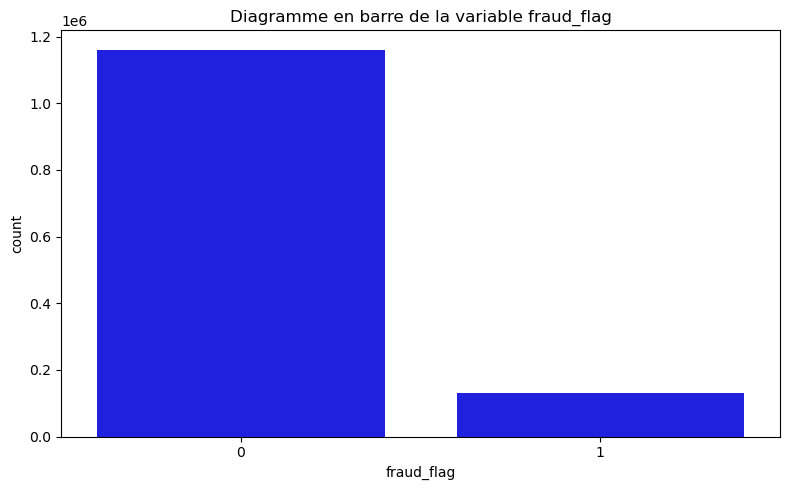

In [15]:
## visualisation de la variable cible
plt.figure(figsize=(8,5))
sns.countplot(data=train, x='fraud_flag', color='b')
plt.title('Diagramme en barre de la variable fraud_flag')
plt.tight_layout()
plt.show()

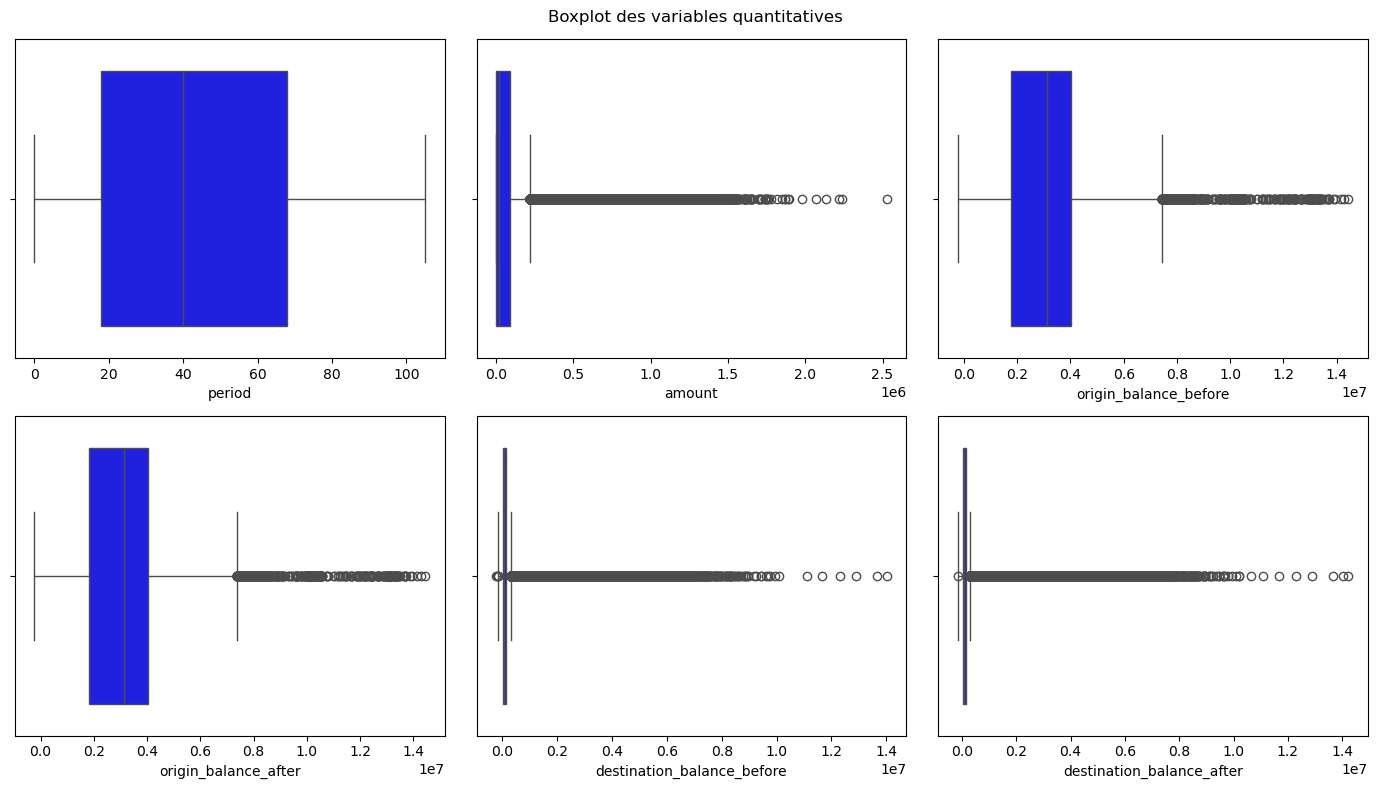

In [16]:
## verification des valeurs abrentes
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Boxplot des variables quantitatives")
for i, var in enumerate(vars_quanti):
    row = i // 3
    col = i % 3
    sns.boxplot(data=train, x=var, ax=axes[row,col], color='b')
plt.tight_layout()
plt.show()

D'apres ces boxplots on observe que les variables amount, origin_balance_before, origin_balance_after, destination_balance_before, destination_balance_after ont des valeurs tres eleve.

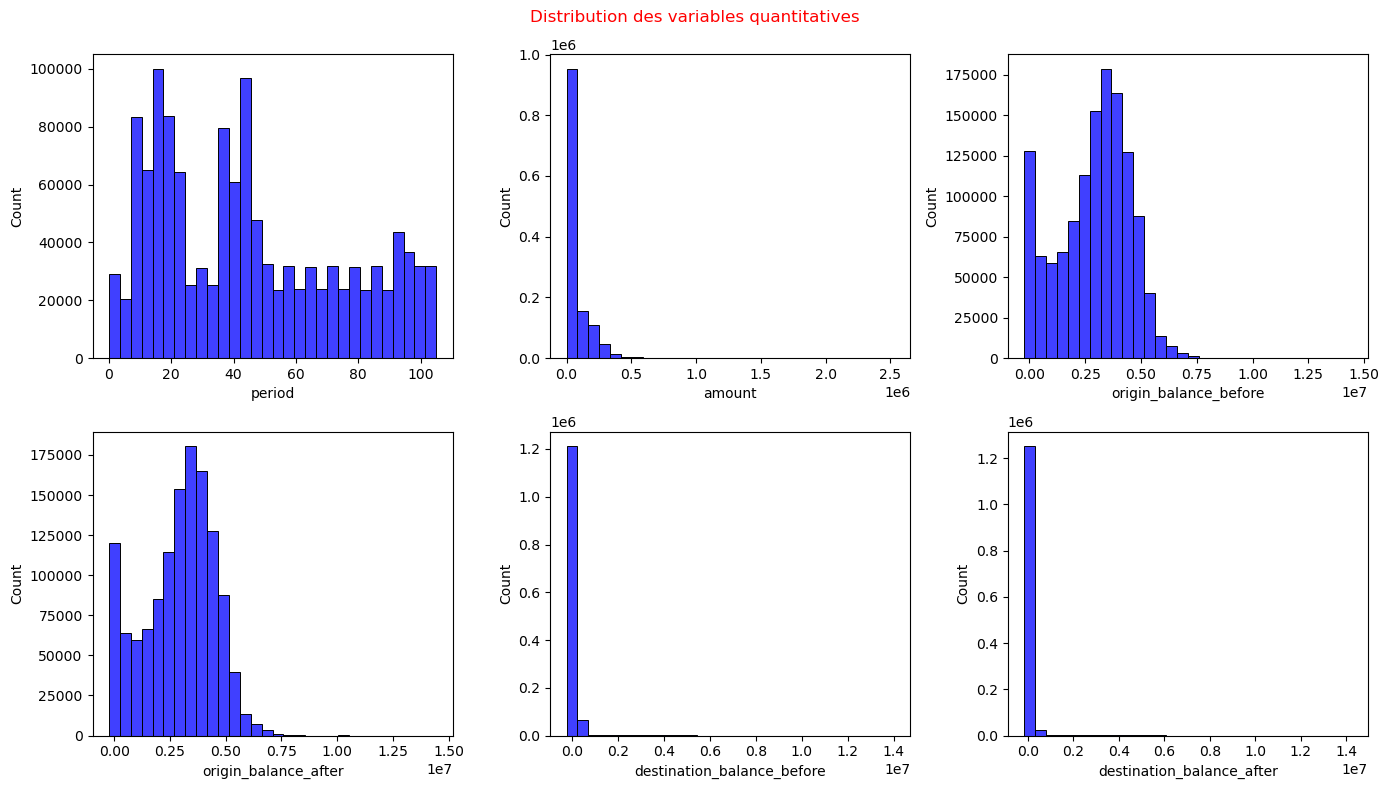

In [17]:
## verifier la distribution des variables quantitatives
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distribution des variables quantitatives", color='r')
for i, var in enumerate(vars_quanti):
    row = i // 3
    col = i % 3
    sns.histplot(data=train, x=var, bins=30, ax=axes[row, col], color='b')
plt.tight_layout()
plt.show()

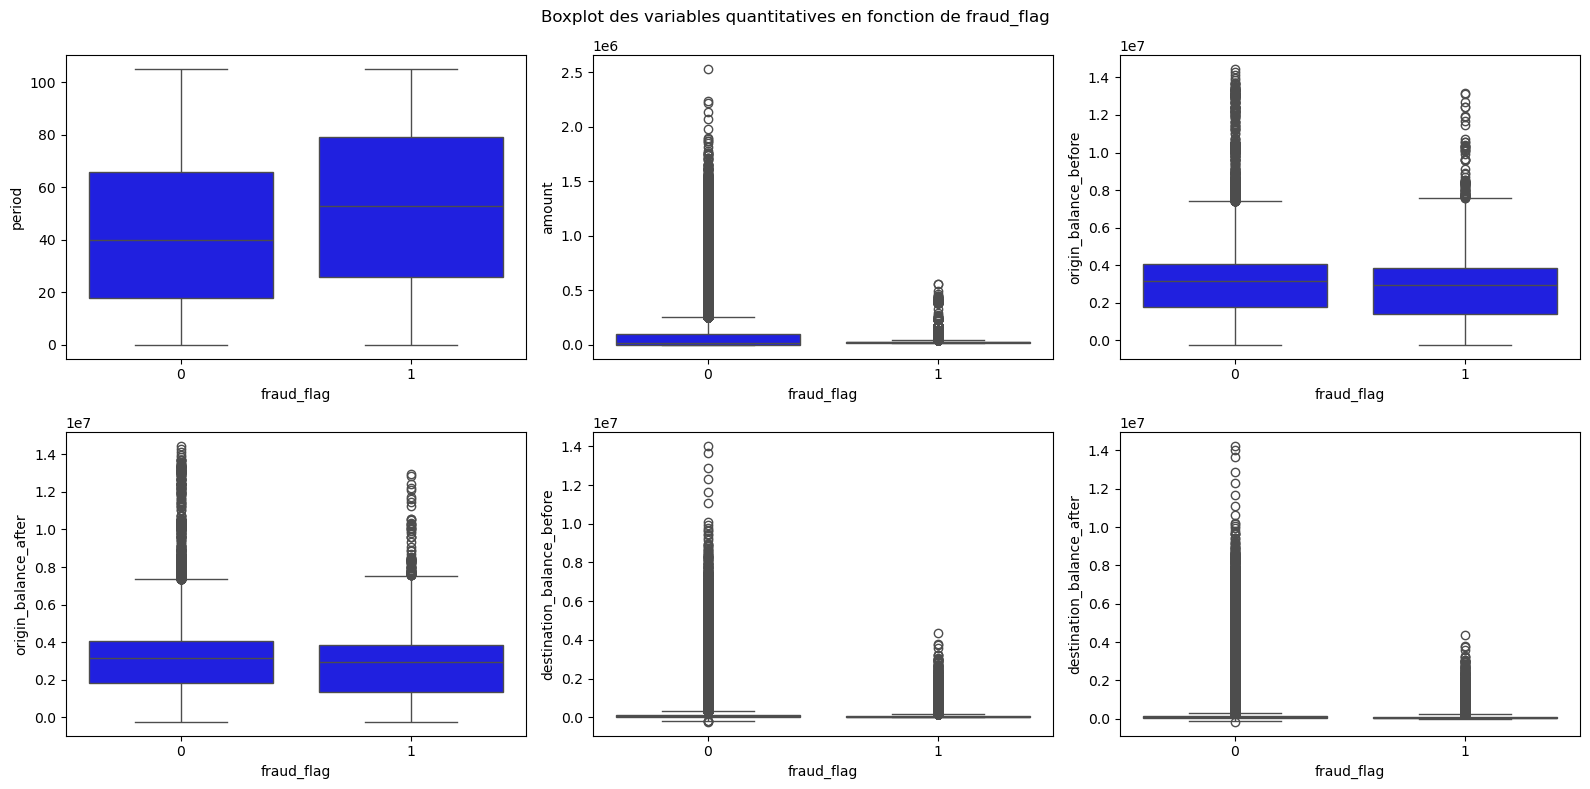

In [18]:
### boxplot en fonction de fraud_flag
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Boxplot des variables quantitatives en fonction de fraud_flag")
for i, var in enumerate(vars_quanti):
    row = i // 3
    col = i % 3
    sns.boxplot(data=train, x='fraud_flag', y=var, ax=axes[row,col], color='b')
plt.tight_layout()
plt.show()

D'apres ces boxplots on constate que les valeurs extreme des variables sont repartit de par et d'autre de fraude ou non fraude

In [7]:
### Vérifier le pourcentage des outliers
def outliers_percentage(data, num):
    # calcul des mesures (positions et dispersions)
    Q1 = data[num].quantile(q=0.25)
    Q3 = data[num].quantile(q=0.75)
    IQR = Q3 - Q1
    minimum = Q1 - 1.5 * IQR
    maximum = Q3 + 1.5 * IQR
    
    # identifier les outliers
    outliers = data[(data[num] < minimum) | (data[num] > maximum)][num]
    pourcentage_outliers = len(outliers) / len(data) * 100
    
    return pourcentage_outliers

In [8]:
### Vérifier pour chaque variable quantitative
print(f'{"Variable":<40} {"Pourcentage Outliers":<20}')
print('-'*62)
for var in vars_quanti:
    print(f'{var:<40} {outliers_percentage(train, var):.2f}%')

Variable                                 Pourcentage Outliers
--------------------------------------------------------------
period                                   0.00%
amount                                   8.60%
origin_balance_before                    0.07%
origin_balance_after                     0.08%
destination_balance_before               2.88%
destination_balance_after                3.41%


In [9]:
### representer les variables selons fraud_flag
pd.crosstab(index = train['operation'], columns = train["fraud_flag"])

fraud_flag,0,1
operation,,
op_01,4087,0
op_02,71876,0
op_03,285781,129542
op_04,305443,0
op_05,493352,0


In [10]:
### Analyse amount et fraud_flag
print("Statistiques des montants par classe :")
print(train.groupby('fraud_flag')['amount'].describe().T.round(2))

Statistiques des montants par classe :
fraud_flag           0          1
count       1160539.00  129542.00
mean          67968.69   30042.60
std          110417.31   20999.31
min               0.37   19815.43
25%             708.33   20146.40
50%           20224.37   23149.76
75%          101133.18   28897.85
max         2526957.67  559774.43


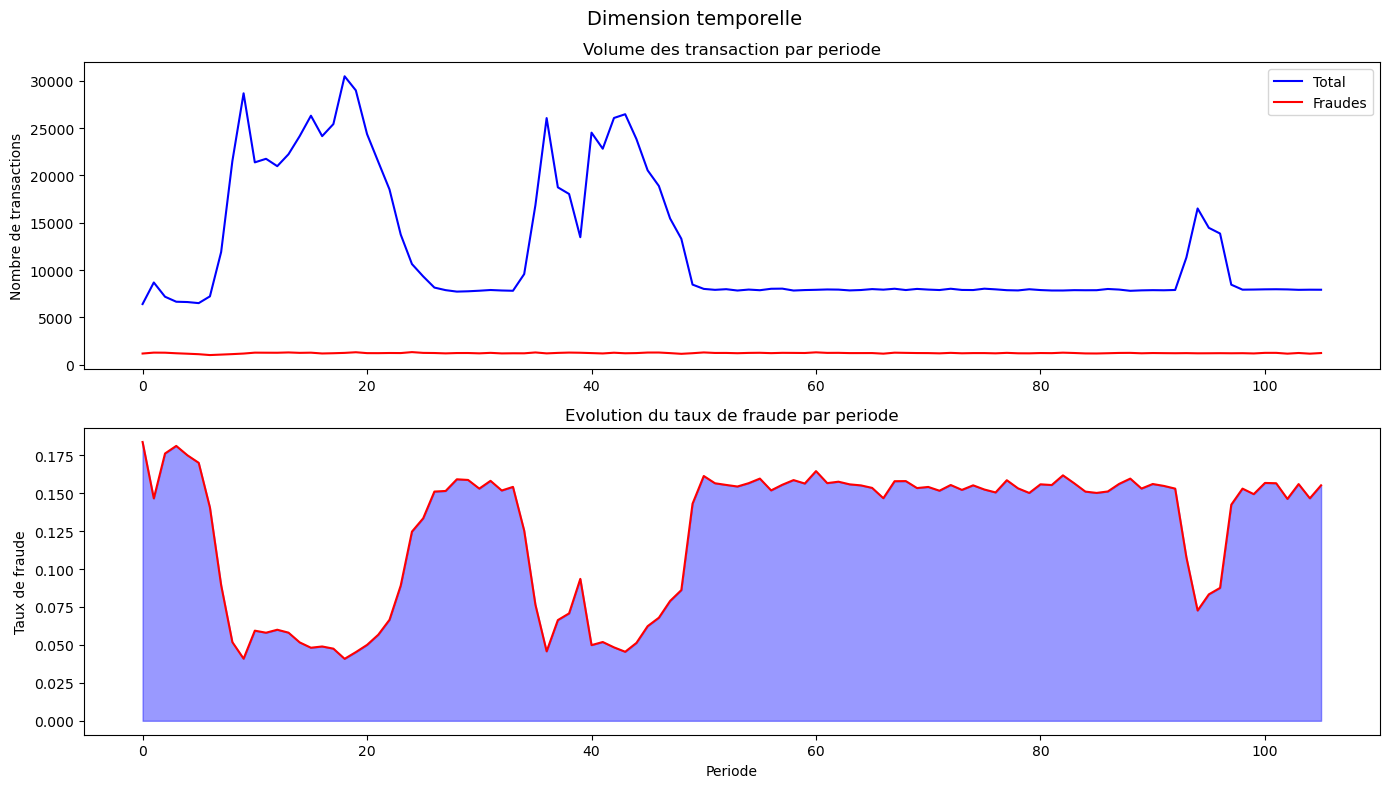

In [24]:
### grouper les periodes
stat_periode = train.groupby('period').agg(
    nbre_transactions = ('fraud_flag', 'count'),
    nbre_fraudes = ('fraud_flag', 'sum'),
    taux_fraudes = ('fraud_flag', 'mean')
).reset_index()

### tracer les graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

### la courbe d'evolution des fraudes en fonction de la periode
axes[0].plot(stat_periode['period'], stat_periode['nbre_transactions'], color='b', label='Total')
axes[0].plot(stat_periode['period'], stat_periode['nbre_fraudes'], color='r', label='Fraudes')
axes[0].set_ylabel('Nombre de transactions')
axes[0].legend()
axes[0].set_title('Volume des transaction par periode')

### la courbe de l'evolution du taux de fraude en fonction du periode
axes[1].fill_between(stat_periode['period'], stat_periode['taux_fraudes'], color='b', alpha=0.4)
axes[1].plot(stat_periode['period'], stat_periode['taux_fraudes'], color='r')
axes[1].set_ylabel('Taux de fraude')
axes[1].set_xlabel('Periode')
axes[1].set_title('Evolution du taux de fraude par periode')

plt.suptitle('Dimension temporelle', fontsize=14)
plt.tight_layout()
plt.show()

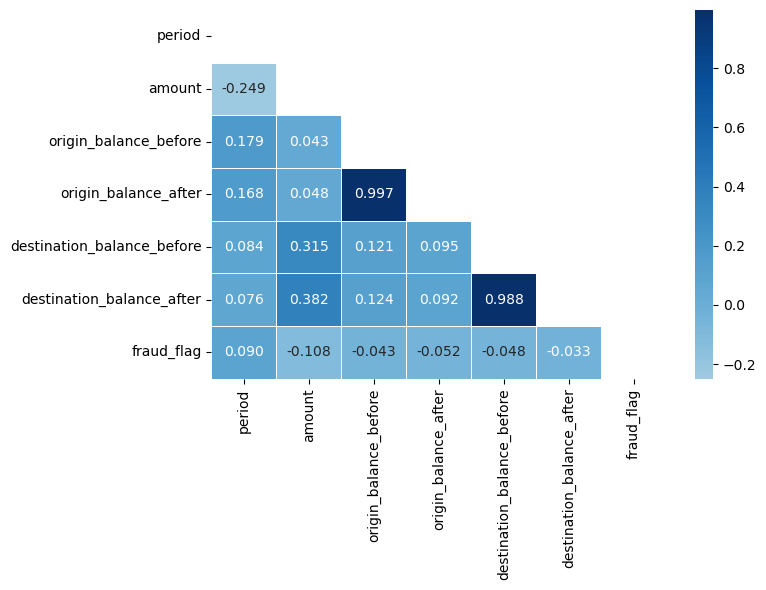

In [11]:
#### correlation des variables quantitatives
## recuperer le nom des variables quantitatives
cor = train.select_dtypes(include=np.number).columns
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(cor, dtype=bool))
sns.heatmap(train[cor].corr(), mask=mask, annot=True, fmt='.3f', cmap='Blues',
            center=0, linewidths=0.5)
plt.tight_layout()
plt.show()

### Copier la base et fait le traitement sur l'operation 3

In [12]:
## Copier la base 
df1 = df[df['operation'] == 'op_03']

NameError: name 'df' is not defined

In [23]:
## verifier la copie
df1.head()

,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
3,dtf_0000004_240f3dae,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0
4,dtf_0000005_f18939e7,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0
8,dtf_0000009_7388f093,0,op_03,96800.66,acc_o_9cc0fd44ac3f05d3,-658.41,-97459.06,acc_d_a0682983bf40c207,70.76,96871.41,1
10,dtf_0000011_58fadec3,0,op_03,90750.60,acc_o_0c61717ed68e61fd,-649.86,-91400.46,acc_d_1ce15ebc7bcefced,63273.65,154024.25,0
12,dtf_0000013_34de3021,0,op_03,49113.00,acc_o_531f90959a53b867,11634.05,11634.05,acc_d_ad75f6676276c61d,3.23,3.23,0


In [24]:
## verifier la base
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 415323 entries, 3 to 1290080
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          415323 non-null  object 
 1   period                      415323 non-null  int64  
 2   operation                   415323 non-null  object 
 3   amount                      415323 non-null  float64
 4   origin_account              415323 non-null  object 
 5   origin_balance_before       415323 non-null  float64
 6   origin_balance_after        415323 non-null  float64
 7   destination_account         415323 non-null  object 
 8   destination_balance_before  415323 non-null  float64
 9   destination_balance_after   415323 non-null  float64
 10  fraud_flag                  415323 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 38.0+ MB


In [25]:
## verifier la base 
df1.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
period,415323.0,53.562,29.635,0.00,28.000,53.00,79.000,105.00
amount,415323.0,50302.202,117635.281,23.49,20203.970,23235.07,32016.010,2526957.67
origin_balance_before,415323.0,2912586.145,1532505.601,-235838.15,1969290.840,3157253.79,3985017.840,14439035.48
origin_balance_after,415323.0,2864434.129,1518371.817,-235838.15,1928116.665,3108309.13,3931089.060,14286193.03
destination_balance_before,415323.0,143592.459,565945.931,-233917.64,0.000,23651.97,83055.780,14015520.35
destination_balance_after,415323.0,191744.475,640766.914,-160051.49,25137.360,58422.53,114834.595,14228571.06
fraud_flag,415323.0,0.312,0.463,0.00,0.000,0.00,1.000,1.00


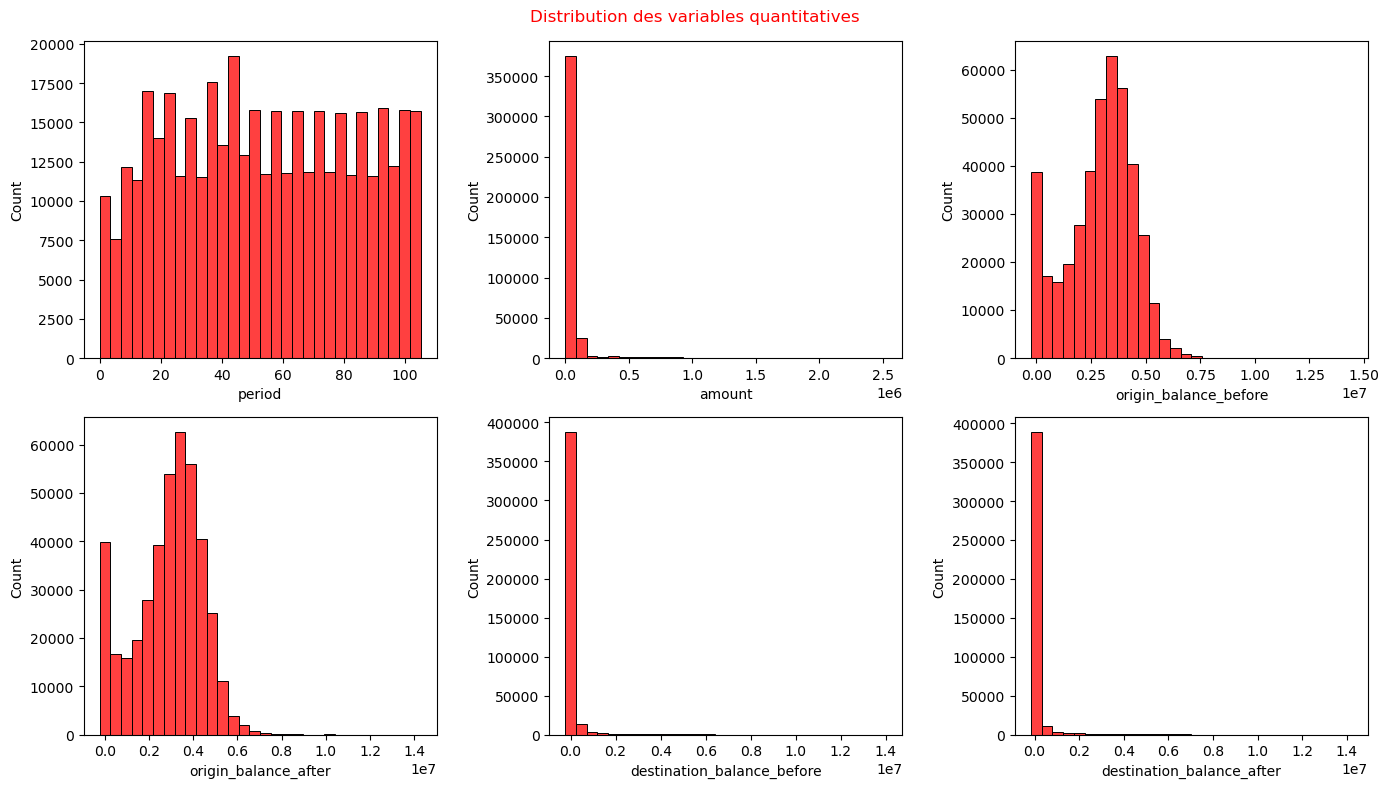

In [26]:
## verifier la distribution des variables quantitatives
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distribution des variables quantitatives", color='r')
for i, var in enumerate(vars_quanti):
    row = i // 3
    col = i % 3
    sns.histplot(data=df1, x=var, bins=30, ax=axes[row, col], color='r')
plt.tight_layout()
plt.show()

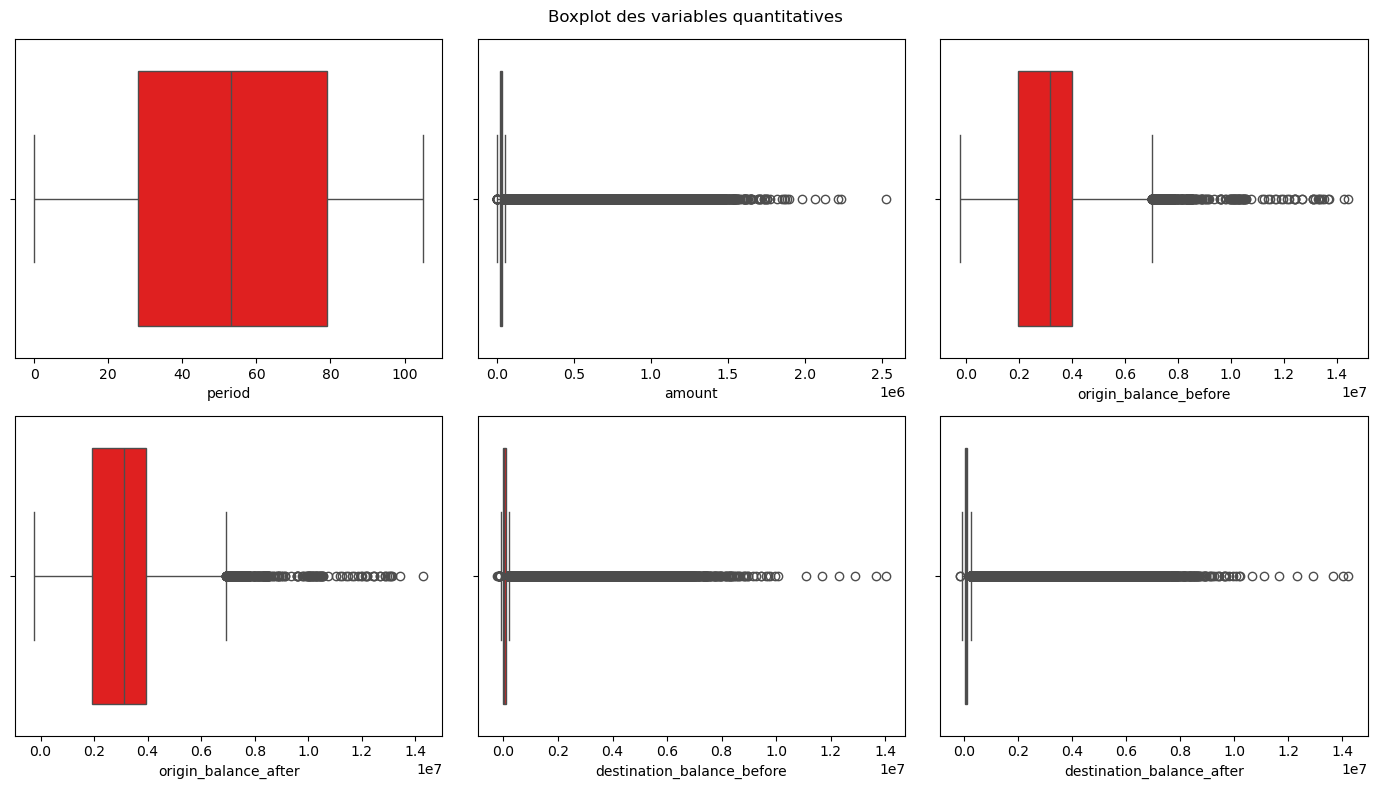

In [27]:
## verification des valeurs abrentes
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Boxplot des variables quantitatives")
for i, var in enumerate(vars_quanti):
    row = i // 3
    col = i % 3
    sns.boxplot(data=df1, x=var, ax=axes[row,col], color='r')
plt.tight_layout()
plt.show()

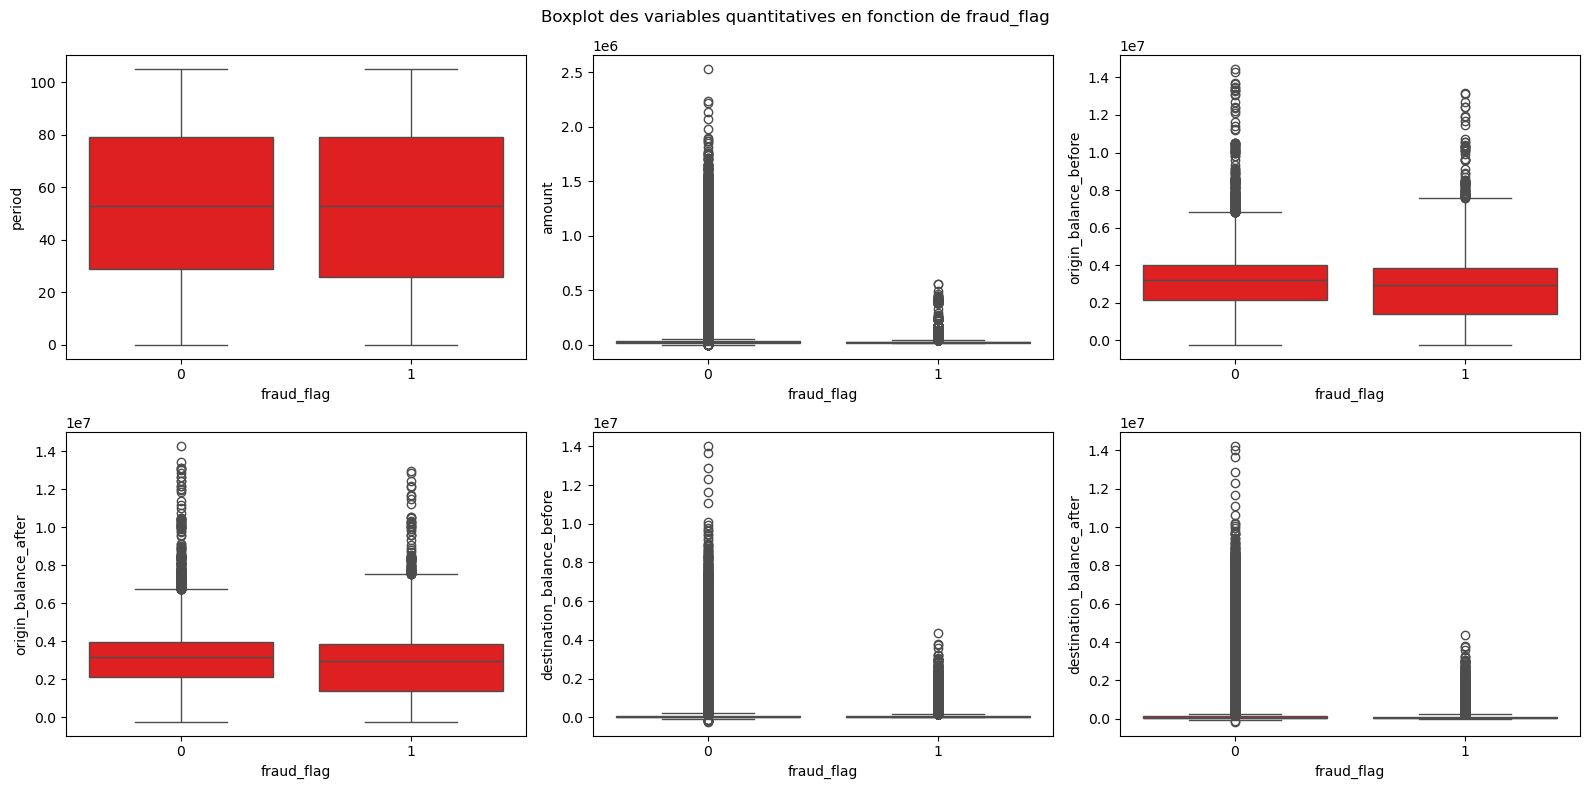

In [28]:
### boxplot en fonction de fraud_flag
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Boxplot des variables quantitatives en fonction de fraud_flag")
for i, var in enumerate(vars_quanti):
    row = i // 3
    col = i % 3
    sns.boxplot(data=df1, x='fraud_flag', y=var, ax=axes[row,col], color='r')
plt.tight_layout()
plt.show()

In [29]:
### Vérifier pour chaque variable quantitative
print(f'{"Variable":<40} {"Pourcentage Outliers":<20}')
print('-'*62)
for var in vars_quanti:
    print(f'{var:<40} {outliers_percentage(df1, var):.2f}%')

Variable                                 Pourcentage Outliers
--------------------------------------------------------------
period                                   0.00%
amount                                   11.62%
origin_balance_before                    0.16%
origin_balance_after                     0.16%
destination_balance_before               8.01%
destination_balance_after                8.50%
